# 04 - Avaliação (Precision/Recall) e Tuning

**O que este notebook faz:** injeta anomalias sintéticas no conjunto de teste (para ter um rótulo de verdade), mede precision/recall/F1/ROC-AUC/PR-AUC dos 4 modelos, faz um tuning simples do hiperparâmetro `contamination`/`nu`, escolhe o melhor modelo e salva o resultado final em `models/` e `reports/`. É o último passo do fluxo EDA -> baseline -> modelos -> tuning -> avaliação.

**Problema a resolver:** o dataset da ANP não tem rótulo de 'isto é uma anomalia'. Para medir a métrica principal do projeto — precision/recall nos outliers — injetamos **anomalias sintéticas** no conjunto de teste (nunca no treino): alteramos drasticamente o preço de uma fração pequena e aleatória de postos, simulando erro de digitação ou preço fora da realidade de mercado, e guardamos essas linhas como rótulo verdadeiro.

Com esse rótulo sintético, avaliamos os 4 modelos treinados no notebook `03_modelagem_comparacao` e ajustamos hiperparâmetros.

## 1. Imports

Bibliotecas e funções já usadas nos notebooks anteriores, mais `precision_recall_curve` para as curvas da seção 5.

In [1]:
import sys
sys.path.append('..')

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

from src.features import ReferenciaPrecos
from src.models import construir_modelos, prever_anomalias
from src.evaluation import injetar_anomalias_sinteticas, calcular_metricas

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Carregar split, preprocessador e preparar X_treino

Reaproveita o treino/teste e o preprocessador salvos no notebook 02, e já transforma `X_treino` — ele será usado para treinar todos os modelos nas próximas seções.

In [2]:
treino = pd.read_csv('../data/treino.csv', parse_dates=['data_coleta'])
teste = pd.read_csv('../data/teste.csv', parse_dates=['data_coleta'])

referencia = joblib.load('../models/referencia_precos.joblib')
preprocessador = joblib.load('../models/preprocessador.joblib')

# X_treino nunca recebe anomalia sintética — só o teste é alterado abaixo,
# senão os modelos aprenderiam a tratar as anomalias como padrão normal.
treino_feat = referencia.transform(treino)
X_treino = preprocessador.transform(treino_feat)

## 3. Injetar anomalias sintéticas no teste

Dois cenários: um com anomalias **extremas** (preço multiplicado/dividido por 2x a 4x — erro grosseiro de digitação) e outro com anomalias **moderadas** (1.3x a 1.8x — um posto só um pouco fora da curva), para ver como a dificuldade de detecção muda conforme a anomalia fica mais sutil.

In [3]:
teste_extremo, y_extremo = injetar_anomalias_sinteticas(
    teste, frac=0.02, fator_min=2.0, fator_max=4.0, seed=42
)
teste_moderado, y_moderado = injetar_anomalias_sinteticas(
    teste, frac=0.02, fator_min=1.3, fator_max=1.8, seed=42
)

print('Anomalias injetadas (extremo):', y_extremo.sum(), '/', len(y_extremo))
print('Anomalias injetadas (moderado):', y_moderado.sum(), '/', len(y_moderado))

Anomalias injetadas (extremo): 261 / 13084
Anomalias injetadas (moderado): 261 / 13084


In [4]:
def preparar_X(df_bruto):
    """Aplica a mesma referência de medianas e o mesmo preprocessador
    ajustados no treino (notebook 02) a um DataFrame bruto qualquer,
    devolvendo a matriz pronta para entrar nos modelos."""
    feat = referencia.transform(df_bruto)
    return preprocessador.transform(feat)

X_teste_extremo = preparar_X(teste_extremo)
X_teste_moderado = preparar_X(teste_moderado)

**Resultado:** 261 anomalias sintéticas em cada cenário (2% de 13.084 linhas do teste) — a mesma quantidade nos dois casos, só muda a intensidade da alteração de preço (fator 2x-4x vs. 1.3x-1.8x).

## 4. Avaliar os 4 modelos (contamination=0.02) nos dois cenários

Cada modelo é treinado uma vez em `X_treino` e avaliado nos dois conjuntos de teste com anomalia injetada (extremo e moderado), reunindo precision/recall/F1/ROC-AUC/PR-AUC numa única tabela.

In [5]:
modelos = construir_modelos(contamination=0.02)
for modelo in modelos.values():
    modelo.fit(X_treino)

linhas = []
cenarios = {
    'extremo': (X_teste_extremo, y_extremo),
    'moderado': (X_teste_moderado, y_moderado),
}
resultados_score = {}
for nome, modelo in modelos.items():
    for cenario, (X_c, y_c) in cenarios.items():
        rotulo, score = prever_anomalias(modelo, X_c)
        resultados_score[(nome, cenario)] = (y_c, score)
        m = calcular_metricas(y_c, rotulo, score)
        linhas.append({'modelo': nome, 'cenario': cenario, **m})

avaliacao = pd.DataFrame(linhas)
avaliacao.sort_values(['cenario', 'f1'], ascending=[True, False])

,modelo,cenario,precision,recall,f1,roc_auc,pr_auc
0,IsolationForest,extremo,0.476395,0.850575,0.610729,0.991856,0.707226
4,OneClassSVM,extremo,0.424390,1.000000,0.595890,1.000000,1.000000
6,EllipticEnvelope,extremo,0.284987,0.429119,0.342508,0.929394,0.432615
2,LocalOutlierFactor,extremo,0.000000,0.000000,0.000000,0.907054,0.095984
5,OneClassSVM,moderado,0.422512,0.992337,0.592677,0.995259,0.979833
1,IsolationForest,moderado,0.463736,0.808429,0.589385,0.989431,0.640024
7,EllipticEnvelope,moderado,0.223757,0.310345,0.260032,0.842889,0.294116
3,LocalOutlierFactor,moderado,0.000000,0.000000,0.000000,0.883399,0.076880


**Resultado:** no cenário extremo, IsolationForest (F1≈0,61) e OneClassSVM (F1≈0,60, recall=1.0) saem na frente; EllipticEnvelope fica bem atrás (F1≈0,34); e **LocalOutlierFactor detecta zero anomalias no rótulo binário** (precision=recall=0), apesar de ter um ROC-AUC razoável (~0,91) — ou seja, o score do LOF até ordena bem os casos anômalos, mas o limiar padrão do `predict` (calibrado pelo `contamination`) não está cortando no lugar certo para este conjunto. No cenário moderado os F1 caem um pouco para todos (anomalias mais sutis são mais difíceis), mas a ordem entre modelos se mantém parecida.

## 5. Curvas Precision-Recall

Como o rótulo previsto (`predict`) depende do limiar interno de cada modelo (`contamination`/`nu`), a curva PR usando o **score contínuo** mostra o potencial real de cada modelo, independente do limiar escolhido — e é aqui que o LocalOutlierFactor mostra que seu score não é inútil, só o limiar padrão que não ajuda.

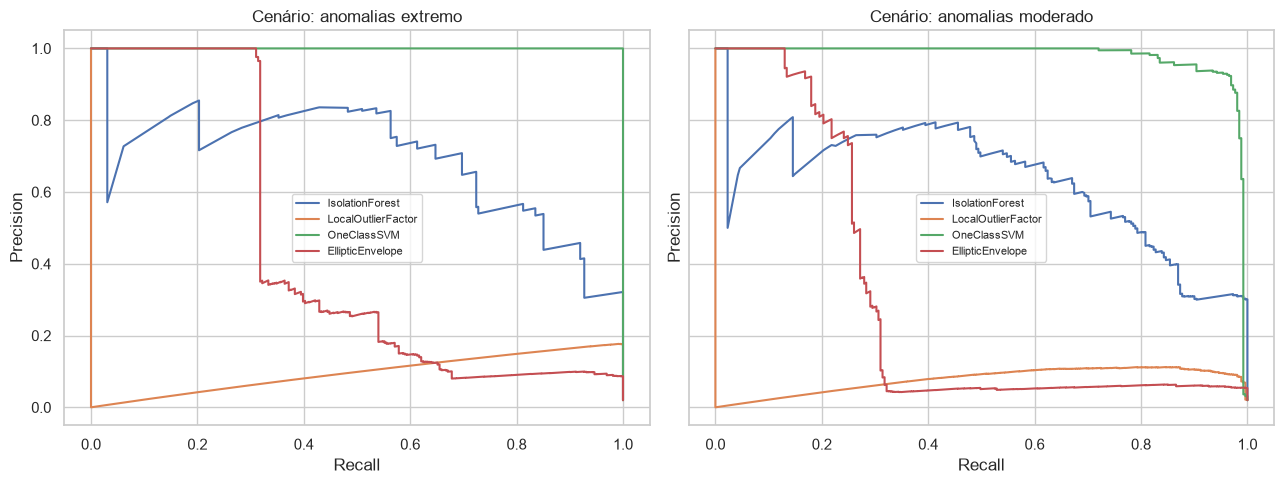

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, cenario in zip(eixos, ['extremo', 'moderado']):
    for nome in modelos:
        y_c, score = resultados_score[(nome, cenario)]
        precisao, revocacao, _ = precision_recall_curve(y_c, score)
        ax.plot(revocacao, precisao, label=nome)
    ax.set_title(f'Cenário: anomalias {cenario}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../reports/curvas_precision_recall.png', dpi=120)
plt.show()

**Resultado:** OneClassSVM tem a curva PR mais próxima do canto superior direito (PR-AUC≈1.0 no cenário extremo, ≈0,98 no moderado) — o score dele separa quase perfeitamente as anomalias injetadas do restante. IsolationForest vem em seguida (PR-AUC ≈0,70 e ≈0,64). LocalOutlierFactor, apesar do rótulo binário inútil na seção anterior, tem PR-AUC bem acima do acaso (baseline seria ≈0,02, a proporção de anomalias), confirmando que o problema é só o limiar.

## 6. Tuning de hiperparâmetros

Grade simples sobre `contamination`/`nu` (o hiperparâmetro comum aos quatro modelos) no cenário extremo, escolhendo por F1.

In [7]:
grade_contamination = [0.005, 0.01, 0.02, 0.03, 0.05]

linhas_tuning = []
for cont in grade_contamination:
    modelos_c = construir_modelos(contamination=cont)
    for nome, modelo in modelos_c.items():
        modelo.fit(X_treino)
        rotulo, score = prever_anomalias(modelo, X_teste_extremo)
        m = calcular_metricas(y_extremo, rotulo, score)
        linhas_tuning.append({'modelo': nome, 'contamination': cont, **m})

tuning = pd.DataFrame(linhas_tuning)
tuning.sort_values(['modelo', 'contamination'])

,modelo,contamination,precision,recall,f1,roc_auc,pr_auc
3,EllipticEnvelope,0.005,0.535484,0.318008,0.399038,0.929394,0.432615
7,EllipticEnvelope,0.010,0.391509,0.318008,0.350951,0.929394,0.432615
11,EllipticEnvelope,0.020,0.284987,0.429119,0.342508,0.929394,0.432615
15,EllipticEnvelope,0.030,0.263566,0.521073,0.350064,0.929394,0.432615
19,EllipticEnvelope,0.050,0.180573,0.555556,0.272556,0.929394,0.432615
0,IsolationForest,0.005,0.737327,0.613027,0.669456,0.991856,0.707226
4,IsolationForest,0.010,0.617647,0.724138,0.666667,0.991856,0.707226
8,IsolationForest,0.020,0.476395,0.850575,0.610729,0.991856,0.707226
12,IsolationForest,0.030,0.390953,0.927203,0.550000,0.991856,0.707226
16,IsolationForest,0.050,0.284624,1.000000,0.443124,0.991856,0.707226


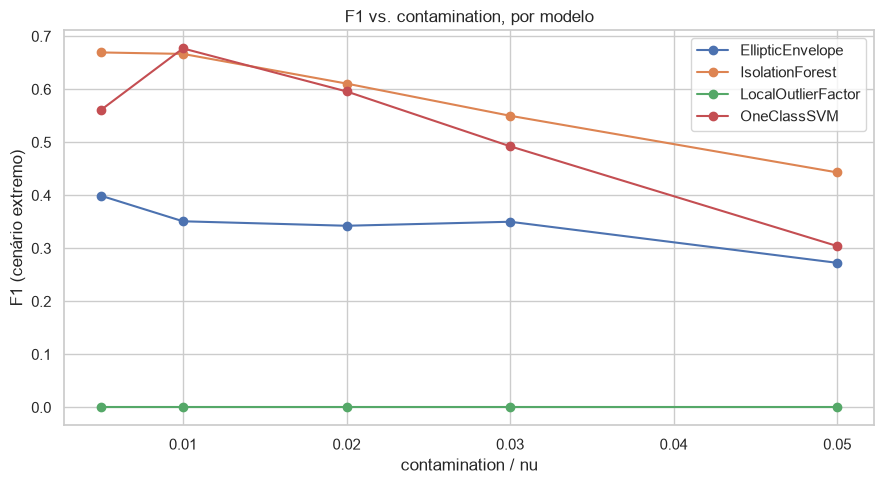

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for nome, grupo in tuning.groupby('modelo'):
    ax.plot(grupo['contamination'], grupo['f1'], marker='o', label=nome)
ax.set_xlabel('contamination / nu')
ax.set_ylabel('F1 (cenário extremo)')
ax.set_title('F1 vs. contamination, por modelo')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/tuning_f1_vs_contamination.png', dpi=120)
plt.show()

**Resultado:** o F1 do IsolationForest cai de forma consistente conforme `contamination` sobe de 0,005 para 0,05 (0,67 -> 0,44), porque o modelo passa a marcar cada vez mais pontos normais como anomalia (recall sobe, precision despenca). OneClassSVM segue o mesmo padrão mas com o pico de F1 em 0,01 (0,68). EllipticEnvelope fica sempre abaixo dos outros dois. Ou seja: `contamination` baixo (perto da fração real de anomalias, ~1-2% como visto na EDA) tende a dar melhor F1 do que valores altos 'por segurança'.

## 7. Escolher o melhor modelo

Dentre todas as combinações modelo × contamination testadas no tuning, pega a que teve o maior F1.

In [9]:
melhor_linha = tuning.loc[tuning['f1'].idxmax()]
melhor_modelo_nome = melhor_linha['modelo']
melhor_contamination = melhor_linha['contamination']
print('Melhor combinação:')
print(melhor_linha)

Melhor combinação:
modelo           OneClassSVM
contamination           0.01
precision           0.511765
recall                   1.0
f1                  0.677043
roc_auc                  1.0
pr_auc                   1.0
Name: 6, dtype: object


**Resultado:** a melhor combinação do grid foi **OneClassSVM com contamination/nu=0,01** (F1≈0,68, recall=1.0, precision≈0,51). Na prática isso significa que o modelo final capturaria todas as anomalias sintéticas do cenário extremo, ao custo de aproximadamente metade dos alertas serem falsos positivos — um trade-off razoável quando o custo de revisar um alerta é menor do que o custo de deixar passar uma anomalia real.

## 8. Treinar o modelo final e salvar

Re-treina o modelo escolhido com o hiperparâmetro ajustado (usando apenas `X_treino`, sem qualquer anomalia sintética) e salva o modelo final e a tabela de avaliação/tuning em `models/` e `reports/`.

In [10]:
modelos_finais = construir_modelos(contamination=melhor_contamination)
modelo_final = modelos_finais[melhor_modelo_nome]
modelo_final.fit(X_treino)

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)
joblib.dump(modelo_final, '../models/melhor_modelo.joblib')

avaliacao.to_csv('../reports/avaliacao_modelos.csv', index=False)
tuning.to_csv('../reports/tuning_contamination.csv', index=False)

print(f'Modelo final salvo: {melhor_modelo_nome} (contamination={melhor_contamination})')

Modelo final salvo: OneClassSVM (contamination=0.01)


## 9. Conclusões finais

- Sem rótulo real, anomalias sintéticas (extremas e moderadas) foram a forma encontrada de medir precision/recall de verdade — útil também para simular novos tipos de fraude/erro no futuro.
- O desempenho cai do cenário extremo para o moderado em quase todos os modelos, o que é esperado: anomalias sutis são intrinsecamente mais difíceis de separar do normal.
- OneClassSVM teve o melhor F1 (0,68 com contamination=0,01) e o melhor PR-AUC (~1,0), mas é o modelo mais lento de treinar (visto no notebook 03) — um trade-off a considerar se o volume de dados crescer muito.
- LocalOutlierFactor foi o caso mais instrutivo: seu score separa bem as anomalias (ROC-AUC/PR-AUC acima do acaso), mas o limiar padrão do `predict` não sinalizou nenhuma — reforça que, na prática, vale a pena olhar a curva PR/score contínuo em vez de confiar cegamente no rótulo binário de qualquer modelo.
- O `contamination`/`nu` ideal depende de quanto se aceita sacrificar precision por mais recall — a grade em `tuning` materializa esse trade-off.
- Modelo final e hiperparâmetros ficam salvos em `models/melhor_modelo.joblib`, prontos para serem aplicados em levantamentos futuros da ANP.